## Draw Facial Features on Randomly Selected Frame

This notebook demonstrates the process of:
1. Loading a video file
2. Randomly selecting a frame from the video
3. Using MediaPipe Face Landmarker (Vision Tasks API) to detect facial landmarks
4. Drawing the facial features on the selected frame
5. Displaying the result

### Step 1: Import Required Libraries

We need OpenCV for video processing, MediaPipe Vision Tasks API for facial landmark detection, NumPy for numerical operations, and Matplotlib for visualization.

In [41]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path

print(f"MediaPipe version: {mp.__version__}")

MediaPipe version: 0.10.32


### Step 2: Define Video Path and Task Model Path

We specify the paths to the video file and the MediaPipe Face Landmarker task model.

In [42]:
# Define video file path
video_path = Path("../3100831007.avi")

# Define MediaPipe task model path
task_model_path = Path("../face_landmarker_v2_with_blendshapes.task")

# Verify files exist
if not video_path.exists():
    raise FileNotFoundError(f"Video file not found: {video_path}")

if not task_model_path.exists():
    raise FileNotFoundError(f"Task model not found: {task_model_path}")

print(f"Video file found: {video_path}")
print(f"Task model found: {task_model_path}")

Video file found: ../3100831007.avi
Task model found: ../face_landmarker_v2_with_blendshapes.task


### Step 3: Load Video and Get Properties

We open the video file and retrieve the total number of frames to determine the valid range for random selection.

In [43]:
# Open the video file
cap = cv2.VideoCapture(str(video_path))

if not cap.isOpened():
    raise IOError(f"Cannot open video file: {video_path}")

# Get video properties
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Video Properties:")
print(f"  - Total frames: {total_frames}")
print(f"  - FPS: {fps:.2f}")
print(f"  - Resolution: {width}x{height}")
print(f"  - Duration: {total_frames/fps:.2f} seconds")

Video Properties:
  - Total frames: 300
  - FPS: 30.00
  - Resolution: 640x480
  - Duration: 10.00 seconds


### Step 4: Randomly Select a Frame Index

We generate a random frame index within the valid range [0, total_frames - 1].

In [44]:
# Generate random frame index
random_frame_idx = random.randint(0, total_frames - 1)
print(f"Randomly selected frame index: {random_frame_idx}")
print(f"Timestamp: {random_frame_idx/fps:.2f} seconds")

Randomly selected frame index: 112
Timestamp: 3.73 seconds


### Step 5: Extract the Selected Frame

We seek to the randomly selected frame position and read the frame from the video.

In [45]:
# Set the video capture to the selected frame position
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)

# Read the frame
ret, frame = cap.read()

if not ret:
    raise IOError(f"Failed to read frame at index {random_frame_idx}")

# Release the video capture
cap.release()

# Convert from BGR (OpenCV) to RGB (MediaPipe/Matplotlib)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

print(f"Frame extracted successfully. Shape: {frame_rgb.shape}")

Frame extracted successfully. Shape: (480, 640, 3)


### Step 6: Display Original Frame

We display the original frame before applying facial landmark detection to see the raw input.

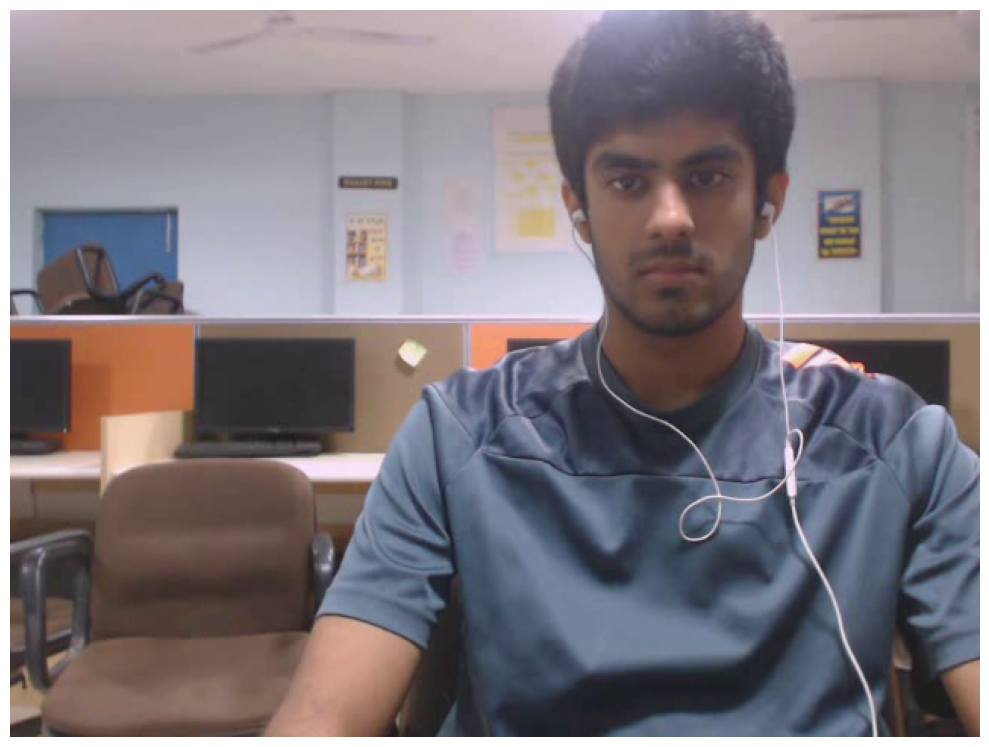

In [61]:
# Display the original frame
plt.figure(figsize=(10, 8))
plt.imshow(frame_rgb)
# plt.title(f"Original Frame (Index: {random_frame_idx})")
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 7: Initialize MediaPipe Face Landmarker

We create a FaceLandmarker instance using the Vision Tasks API with the provided task model file.

In [53]:
# Create FaceLandmarker options
base_options = python.BaseOptions(model_asset_path=str(task_model_path))
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Create the FaceLandmarker instance
face_landmarker = vision.FaceLandmarker.create_from_options(options)

print("FaceLandmarker initialized successfully.")

FaceLandmarker initialized successfully.


W0000 00:00:1779348058.195182 3285989 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1779348058.209335 3285990 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779348058.241976 3286003 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### Step 8: Detect Facial Landmarks Using MediaPipe

We use the FaceLandmarker to detect facial landmarks on the selected frame.

In [54]:
# Create MediaPipe Image from numpy array
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

# Detect facial landmarks
detection_result = face_landmarker.detect(mp_image)

# Check if any face was detected
if not detection_result.face_landmarks:
    print("No face detected in the selected frame.")
else:
    num_faces = len(detection_result.face_landmarks)
    num_landmarks = len(detection_result.face_landmarks[0])
    print(f"Detected {num_faces} face(s)")
    print(f"Number of landmarks per face: {num_landmarks}")
    
    # Print blendshapes if available
    if detection_result.face_blendshapes:
        print(f"\nFace blendshapes detected: {len(detection_result.face_blendshapes[0])}")
        print("Top 5 blendshape scores:")
        sorted_blendshapes = sorted(
            detection_result.face_blendshapes[0], 
            key=lambda x: x.score, 
            reverse=True
        )
        for bs in sorted_blendshapes[:5]:
            print(f"  {bs.category_name}: {bs.score:.4f}")

Detected 1 face(s)
Number of landmarks per face: 478

Face blendshapes detected: 52
Top 5 blendshape scores:
  eyeSquintLeft: 0.3068
  eyeLookUpRight: 0.1844
  eyeLookUpLeft: 0.1788
  eyeSquintRight: 0.1494
  browOuterUpLeft: 0.1376


### Step 9: Draw Facial Landmarks on the Frame

We create a copy of the frame and draw the detected facial landmarks on it using OpenCV drawing functions.

In [57]:
# Create a copy of the frame for drawing
annotated_frame = frame_rgb.copy()

# Define facial feature groups with distinct colors (BGR format for OpenCV)
FACIAL_FEATURES = {
    "Face Oval": {
        "color": (0, 255, 255),  # Yellow
        "connections": [
            (10, 338), (338, 297), (297, 332), (332, 284), (284, 251), (251, 389),
            (389, 356), (356, 454), (454, 323), (323, 361), (361, 288), (288, 397),
            (397, 365), (365, 379), (379, 378), (378, 400), (400, 377), (377, 152),
            (152, 148), (148, 176), (176, 149), (149, 150), (150, 136), (136, 172),
            (172, 58), (58, 132), (132, 93), (93, 234), (234, 127), (127, 162),
            (162, 21), (21, 54), (54, 103), (103, 67), (67, 109), (109, 10),
        ]
    },
    "Left Eye": {
        "color": (255, 0, 0),  # Blue
        "connections": [
            (33, 7), (7, 163), (163, 144), (144, 145), (145, 153), (153, 154),
            (154, 155), (155, 133), (133, 33),  # Closed loop
            (33, 246), (246, 161), (161, 160), (160, 159),
            (159, 158), (158, 157), (157, 173), (173, 133),
        ]
    },
    "Right Eye": {
        "color": (255, 0, 0),  # Blue
        "connections": [
            (263, 249), (249, 390), (390, 373), (373, 374), (374, 380), (380, 381),
            (381, 382), (382, 362), (362, 263),  # Closed loop
            (263, 466), (466, 388), (388, 387), (387, 386),
            (386, 385), (385, 384), (384, 398), (398, 362),
        ]
    },
    "Left Eyebrow": {
        "color": (0, 255, 0),  # Green
        "connections": [
            (46, 53), (53, 52), (52, 65), (65, 55), (55, 107), (107, 66),
            (66, 105), (105, 63), (63, 70),
        ]
    },
    "Right Eyebrow": {
        "color": (0, 255, 0),  # Green
        "connections": [
            (276, 283), (283, 282), (282, 295), (295, 285), (285, 336), (336, 296),
            (296, 334), (334, 293), (293, 300),
        ]
    },
    "Lips (Outer)": {
        "color": (0, 0, 255),  # Red
        "connections": [
            (61, 146), (146, 91), (91, 181), (181, 84), (84, 17), (17, 314),
            (314, 405), (405, 321), (321, 375), (375, 291), (291, 61),  # Closed loop
        ]
    },
    "Lips (Inner)": {
        "color": (255, 0, 255),  # Magenta
        "connections": [
            (78, 95), (95, 88), (88, 178), (178, 87), (87, 14), (14, 317),
            (317, 402), (402, 318), (318, 324), (324, 308), (308, 78),  # Closed loop
        ]
    },
    # "Nose": {
    #     "color": (128, 128, 255),  # Orange
    #     "connections": [
    #         (168, 6), (6, 197), (197, 195), (195, 5), (5, 4), (4, 45), (45, 220),
    #         (220, 115), (115, 48), (48, 219), (219, 221), (221, 49), (49, 218),
    #         (218, 50), (50, 217), (217, 216), (216, 44), (44, 126), (126, 206),
    #         (206, 205), (205, 36), (36, 142), (142, 125), (125, 204), (204, 198),
    #         (198, 211), (211, 46),
    #     ]
    # },
}

# Iris landmark indices (only available with refine_landmarks=True)
LEFT_IRIS_CENTER = 468
RIGHT_IRIS_CENTER = 473
LEFT_IRIS_BOUNDARY = [469, 470, 471, 472]
RIGHT_IRIS_BOUNDARY = [474, 475, 476, 477]

# Eye corner landmarks for computing gaze direction
LEFT_EYE_LEFT = 33
LEFT_EYE_RIGHT = 133
RIGHT_EYE_LEFT = 362
RIGHT_EYE_RIGHT = 263

if detection_result.face_landmarks:
    h, w, _ = annotated_frame.shape
    
    for idx, face_landmarks in enumerate(detection_result.face_landmarks):
        # Draw landmark points (small white dots)
        for landmark in face_landmarks:
            x = int(landmark.x * w)
            y = int(landmark.y * h)
            cv2.circle(annotated_frame, (x, y), 1, (255, 255, 255), -1)
        
        # Draw each facial feature group with its own color
        for feature_name, feature_data in FACIAL_FEATURES.items():
            color = feature_data["color"]
            connections = feature_data["connections"]
            
            for start_idx, end_idx in connections:
                if start_idx < len(face_landmarks) and end_idx < len(face_landmarks):
                    start = face_landmarks[start_idx]
                    end = face_landmarks[end_idx]
                    
                    pt1 = (int(start.x * w), int(start.y * h))
                    pt2 = (int(end.x * w), int(end.y * h))
                    
                    cv2.line(annotated_frame, pt1, pt2, color, 2)
        
        # Draw iris and gaze direction
        if len(face_landmarks) > RIGHT_IRIS_CENTER:  # Check if iris landmarks exist
            iris_color = (255, 255, 0)  # Cyan
            gaze_color = (0, 255, 255)  # Yellow arrows
            
            # Process both eyes
            for iris_center_idx, iris_boundary, eye_left_idx, eye_right_idx, label in [
                (LEFT_IRIS_CENTER, LEFT_IRIS_BOUNDARY, LEFT_EYE_LEFT, LEFT_EYE_RIGHT, "Left"),
                (RIGHT_IRIS_CENTER, RIGHT_IRIS_BOUNDARY, RIGHT_EYE_LEFT, RIGHT_EYE_RIGHT, "Right")
            ]:
                # Get iris center
                iris_center = face_landmarks[iris_center_idx]
                cx = int(iris_center.x * w)
                cy = int(iris_center.y * h)
                
                # Draw iris boundary circle
                iris_pts = []
                for idx in iris_boundary:
                    pt = face_landmarks[idx]
                    iris_pts.append((int(pt.x * w), int(pt.y * h)))
                
                # Draw filled circle for iris
                cv2.fillPoly(annotated_frame, [np.array(iris_pts)], iris_color)
                
                # Compute gaze direction
                eye_left = face_landmarks[eye_left_idx]
                eye_right = face_landmarks[eye_right_idx]
                
                eye_center_x = (eye_left.x + eye_right.x) / 2
                eye_center_y = (eye_left.y + eye_right.y) / 2
                
                # Gaze offset (how far iris is from eye center)
                gaze_offset_x = iris_center.x - eye_center_x
                gaze_offset_y = iris_center.y - eye_center_y
                
                # Scale the arrow length for visibility
                eye_width = abs(eye_right.x - eye_left.x)
                arrow_length = eye_width * 1.5  # Arrow extends beyond eye
                
                # Normalize gaze direction
                gaze_norm = np.sqrt(gaze_offset_x**2 + gaze_offset_y**2)
                if gaze_norm > 0.001:  # Avoid division by zero
                    gaze_dir_x = (gaze_offset_x / gaze_norm) * arrow_length
                    gaze_dir_y = (gaze_offset_y / gaze_norm) * arrow_length
                    
                    # Arrow endpoint
                    arrow_end_x = int(cx + gaze_dir_x)
                    arrow_end_y = int(cy + gaze_dir_y)
                    
                    # Draw gaze arrow
                    cv2.arrowedLine(
                        annotated_frame, 
                        (cx, cy), 
                        (arrow_end_x, arrow_end_y),
                        gaze_color, 
                        3,
                        tipLength=0.3
                    )
                    
                    # Draw gaze endpoint circle
                    cv2.circle(annotated_frame, (arrow_end_x, arrow_end_y), 4, gaze_color, -1)
    
    print("Facial landmarks drawn successfully with color-coded features.")
    print("\nColor legend:")
    print("  ⚪ White  - Landmark points")
    print("  🟡 Yellow - Face Oval")
    print("  🔵 Blue   - Eyes")
    print("  🟢 Green  - Eyebrows")
    print("  🔴 Red    - Lips (Outer)")
    print("  🟣 Magenta - Lips (Inner)")
    print("  🟠 Orange - Nose")
    print("  🔵 Cyan   - Iris")
    print("  🟡 Yellow - Gaze direction arrows")
else:
    print("No landmarks to draw - no face detected.")

Facial landmarks drawn successfully with color-coded features.

Color legend:
  ⚪ White  - Landmark points
  🟡 Yellow - Face Oval
  🔵 Blue   - Eyes
  🟢 Green  - Eyebrows
  🔴 Red    - Lips (Outer)
  🟣 Magenta - Lips (Inner)
  🟠 Orange - Nose
  🔵 Cyan   - Iris
  🟡 Yellow - Gaze direction arrows


### Step 10: Display Annotated Frame with Facial Landmarks

We display the final result with facial landmarks overlaid on the original frame.

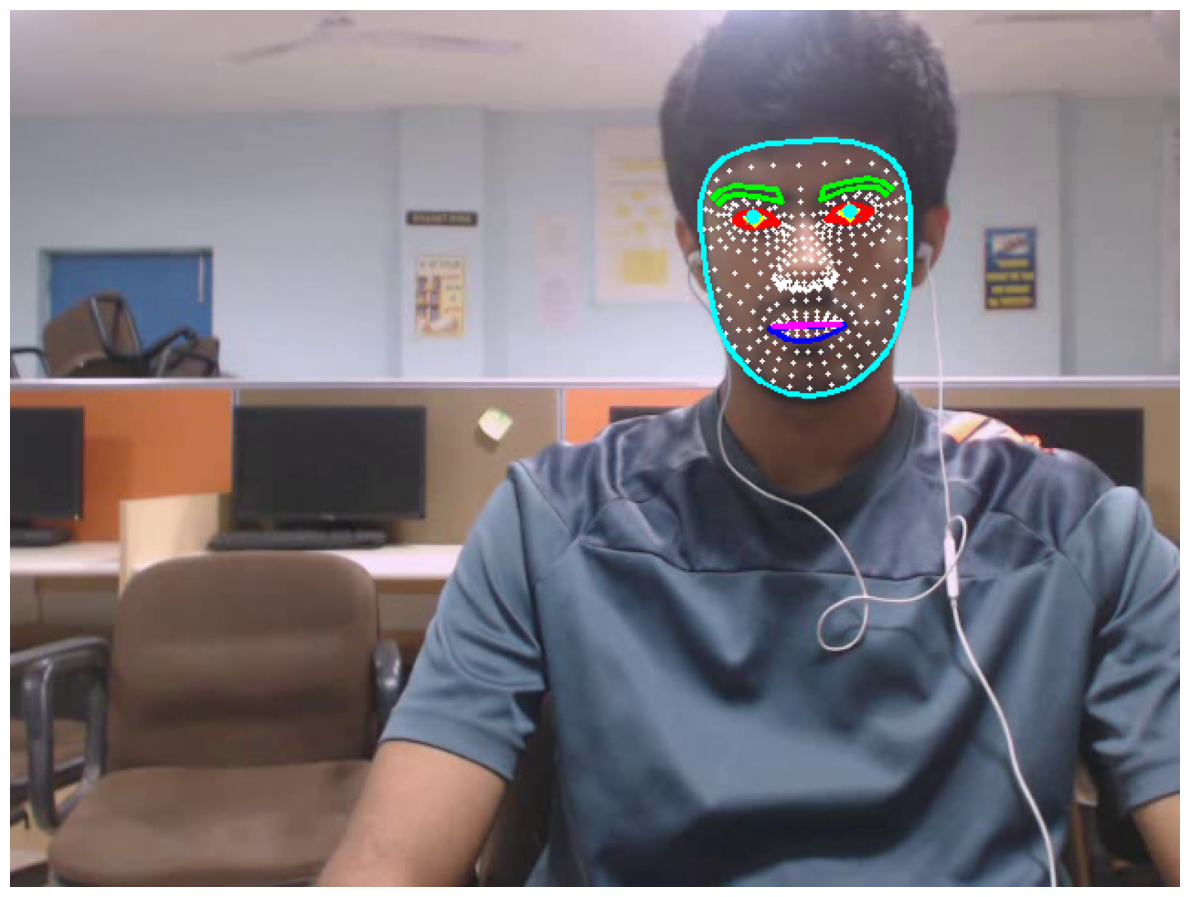

In [59]:
# Display the annotated frame
plt.figure(figsize=(12, 10))
plt.imshow(annotated_frame)
# plt.title(f"Frame with Facial Landmarks (Index: {random_frame_idx})\n478 Landmarks Detected")
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 11: Save the Annotated Frame (Optional)

We can save the annotated frame to a file for later use or documentation.

In [60]:
# Create output directory if it doesn't exist
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

# Define output file path
output_path = output_dir / f"frame_{random_frame_idx}_landmarks.png"

# Convert back to BGR for OpenCV saving
annotated_frame_bgr = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)

# Save the annotated frame
cv2.imwrite(str(output_path), annotated_frame_bgr)
print(f"Annotated frame saved to: {output_path}")

Annotated frame saved to: ../outputs/frame_112_landmarks.png


### Step 12: Extract and Display Landmark Coordinates (Optional)

We can extract the landmark coordinates for further analysis or processing.

In [40]:
if detection_result.face_landmarks:
    # Extract landmarks for the first detected face
    landmarks = detection_result.face_landmarks[0]
    
    # Convert landmarks to numpy array
    landmark_array = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    
    print(f"Landmark coordinates shape: {landmark_array.shape}")
    print(f"\nFirst 5 landmarks (x, y, z normalized coordinates):")
    for i in range(5):
        print(f"  Landmark {i}: x={landmark_array[i, 0]:.4f}, y={landmark_array[i, 1]:.4f}, z={landmark_array[i, 2]:.4f}")
    
    # Convert to pixel coordinates
    h, w, _ = frame_rgb.shape
    landmark_pixels = landmark_array.copy()
    landmark_pixels[:, 0] *= w  # x coordinate
    landmark_pixels[:, 1] *= h  # y coordinate
    
    print(f"\nFirst 5 landmarks (pixel coordinates):")
    for i in range(5):
        print(f"  Landmark {i}: x={landmark_pixels[i, 0]:.1f}, y={landmark_pixels[i, 1]:.1f}, z={landmark_pixels[i, 2]:.4f}")

Landmark coordinates shape: (478, 3)

First 5 landmarks (x, y, z normalized coordinates):
  Landmark 0: x=0.6803, y=0.3454, z=-0.0189
  Landmark 1: x=0.6790, y=0.3127, z=-0.0421
  Landmark 2: x=0.6795, y=0.3226, z=-0.0204
  Landmark 3: x=0.6710, y=0.2750, z=-0.0339
  Landmark 4: x=0.6786, y=0.3014, z=-0.0457

First 5 landmarks (pixel coordinates):
  Landmark 0: x=435.4, y=165.8, z=-0.0189
  Landmark 1: x=434.5, y=150.1, z=-0.0421
  Landmark 2: x=434.8, y=154.8, z=-0.0204
  Landmark 3: x=429.5, y=132.0, z=-0.0339
  Landmark 4: x=434.3, y=144.7, z=-0.0457


## Summary

This notebook demonstrated the complete pipeline for:
1. **Loading a video file** - Using OpenCV's VideoCapture
2. **Random frame selection** - Generating a random index within the valid range
3. **Frame extraction** - Seeking to the selected position and reading the frame
4. **Facial landmark detection** - Using MediaPipe Face Landmarker (Vision Tasks API) to detect 478 landmarks
5. **Visualization** - Drawing landmarks, contours, and iris connections on the frame
6. **Output** - Displaying and optionally saving the annotated result

The MediaPipe Face Landmarker model provides detailed facial geometry that can be used for:
- Affective state recognition (boredom, engagement, confusion, frustration)
- Facial expression analysis
- Head pose estimation
- Gaze tracking
- Feature engineering for machine learning models

**Note:** This notebook uses the MediaPipe Vision Tasks API (v0.10+) with the `.task` model file format, which is the recommended approach for new MediaPipe projects.